<a href="https://colab.research.google.com/github/chandanaa-r/Ride-Fare-Prediction/blob/main/ML_combine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
distance_km=np.random.uniform(1,20,500)

actual_price=(distance_km*15)+40+np.random.normal(0,20,500)

uber_data=pd.DataFrame({
    "Distance_KM":distance_km,
    "Price_INR":actual_price
})

print("here is our uber database:")
print(uber_data.head())

here is our uber database:
   Distance_KM   Price_INR
0     8.116262  168.579053
1    19.063572  363.476994
2    14.907885  282.626750
3    12.374511  214.079595
4     3.964354   81.497019


the ai predicts a 10km ride will cost:$190.04


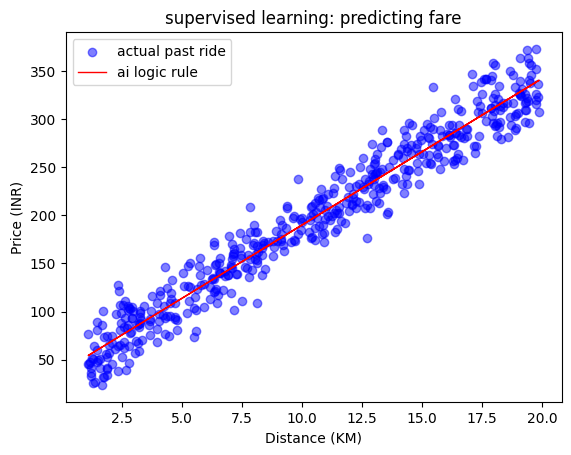

In [18]:
from sklearn.linear_model import LinearRegression

X=uber_data[['Distance_KM']]
y=uber_data['Price_INR']

price_model=LinearRegression()
price_model.fit(X,y)

new_ride=pd.DataFrame({'Distance_KM':[10]})
predicted_fare=price_model.predict(new_ride)

print(f"the ai predicts a 10km ride will cost:${predicted_fare[0]:.2f}")

plt.scatter(X,y,color='blue',alpha=0.5,label='actual past ride')
plt.plot(X,price_model.predict(X),color='red',linewidth=1,label='ai logic rule')
plt.title("supervised learning: predicting fare")
plt.xlabel("Distance (KM)")
plt.ylabel("Price (INR)")
plt.legend()
plt.show()

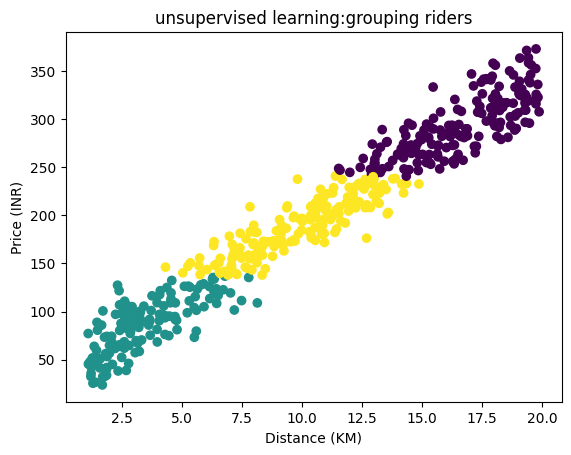

In [21]:
from sklearn.cluster import KMeans

data_for_clustering=uber_data[['Distance_KM','Price_INR']]

clustering_model=KMeans(n_clusters=3,random_state=42,n_init=10)
uber_data['Rider_Type']=clustering_model.fit_predict(data_for_clustering)

plt.scatter(uber_data['Distance_KM'],uber_data['Price_INR'],c=uber_data['Rider_Type'],cmap='viridis')
plt.title("unsupervised learning:grouping riders")
plt.xlabel("Distance (KM)")
plt.ylabel("Price (INR)")

plt.show()

In [22]:
import random
import numpy as np

surge_options = [1.0, 1.5, 2.0]

ai_memory_rewards = [0, 0, 0]
times_tried = [0, 0, 0]

print("AI is learning the best surge price by trial and error...\n")

for ride in range(100):
    action_index = random.randint(0, 2)
    chosen_surge = surge_options[action_index]

    if chosen_surge == 1.0:
        reward = 50
    elif chosen_surge == 1.5:
        reward = 75 if random.random() > 0.2 else 0
    else:
        reward = 100 if random.random() > 0.6 else 0

    ai_memory_rewards[action_index] += reward
    times_tried[action_index] += 1

average_rewards = [
    ai_memory_rewards[i] / (times_tried[i] + 1)
    for i in range(3)
]

for i in range(3):
    print(f"Surge {surge_options[i]}x earned an average of ₹{average_rewards[i]:.2f} per ride.")

best_action = surge_options[np.argmax(average_rewards)]

print(f"\nReinforcement learning complete. AI sets final surge to: {best_action}x")

AI is learning the best surge price by trial and error...

Surge 1.0x earned an average of ₹48.65 per ride.
Surge 1.5x earned an average of ₹54.55 per ride.
Surge 2.0x earned an average of ₹27.27 per ride.

Reinforcement learning complete. AI sets final surge to: 1.5x
